In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [4]:
df = pd.read_csv("leaf.csv")
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mean_R              1000 non-null   float64
 1   Mean_G              1000 non-null   float64
 2   Mean_B              1000 non-null   float64
 3   ExG                 1000 non-null   float64
 4   Gray_Mean           1000 non-null   float64
 5   GLCM_Contrast       1000 non-null   float64
 6   GLCM_Homogeneity    1000 non-null   float64
 7   GLCM_Energy         1000 non-null   float64
 8   Edge_Density        1000 non-null   float64
 9   Contour_Area_Ratio  1000 non-null   float64
 10  Label               1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB
None
            Mean_R       Mean_G       Mean_B          ExG    Gray_Mean  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    136.296229   116.904647    96.533153     0.979912   116

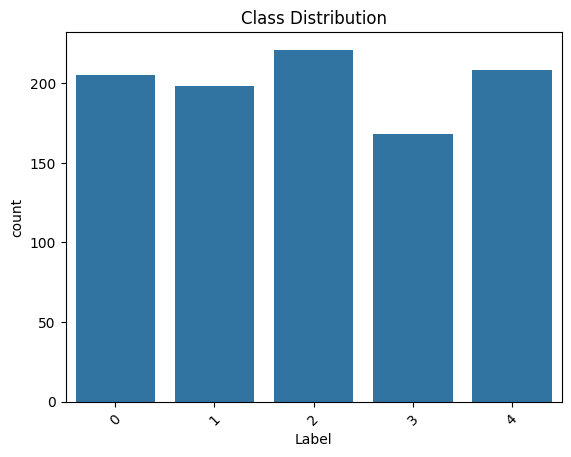

In [5]:
sns.countplot(x="Label", data=df)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

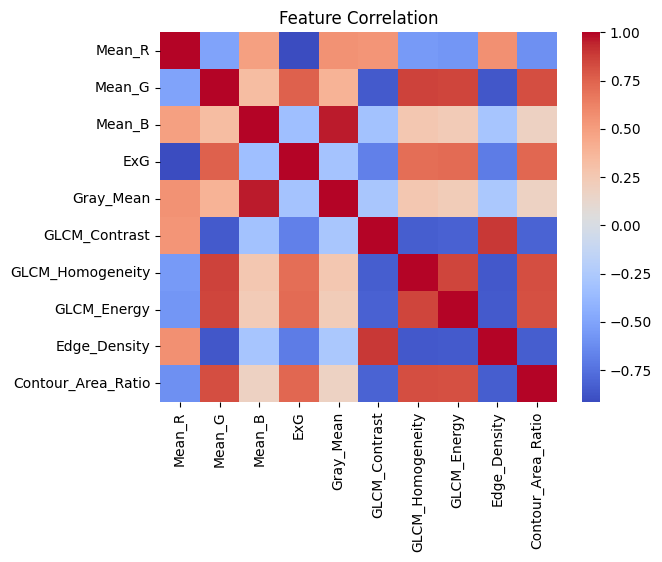

In [6]:
plt.figure()
sns.heatmap(df.drop("Label", axis=1).corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

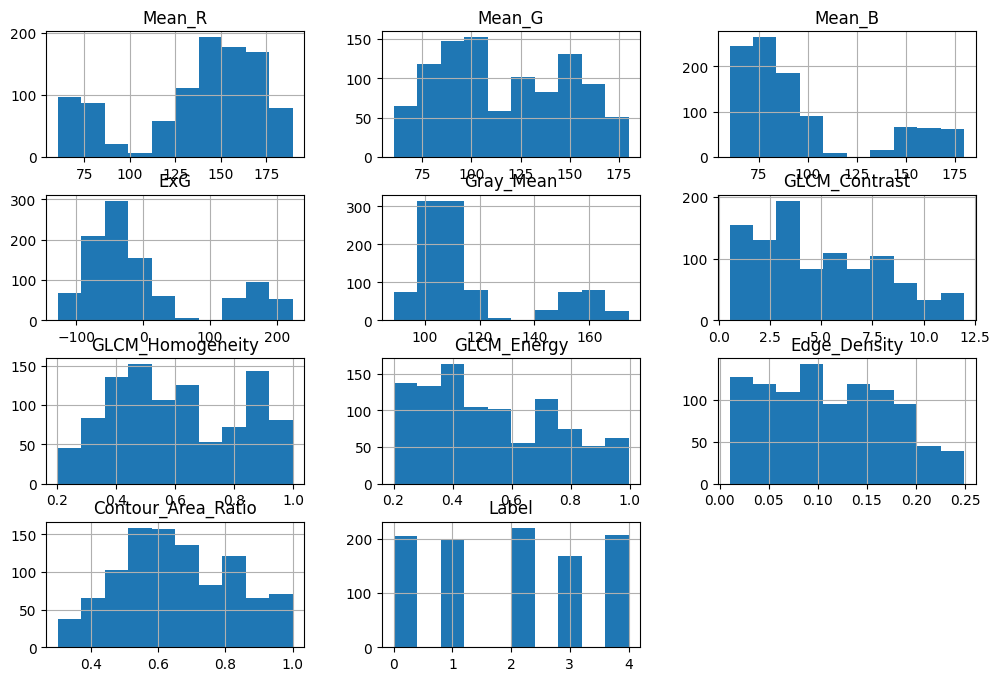

In [7]:
df.hist(figsize=(12,8))
plt.show()

In [8]:
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])

In [9]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [10]:
# 1. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. KNN Imputation (fit only on train)
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# 3. Scaling (fit only on train)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=6)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)
selected_features = df.drop("Label", axis=1).columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Mean_R', 'Mean_B', 'ExG', 'Gray_Mean', 'GLCM_Contrast',
       'Edge_Density'],
      dtype='str')


In [12]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

Random Forest Accuracy: 0.9550
SVM Accuracy: 0.9550
KNN Accuracy: 0.9350


           Model  Accuracy
0  Random Forest     0.955
1            SVM     0.955
2            KNN     0.935


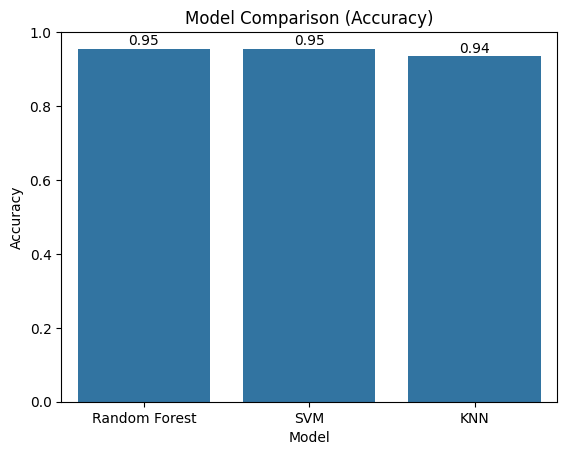

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results to DataFrame
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

# Plot
plt.figure()
ax = sns.barplot(x="Model", y="Accuracy", data=results_df)

# Add exact values on bars
for i, v in enumerate(results_df["Accuracy"]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.title("Model Comparison (Accuracy)")
plt.ylim(0, 1)
plt.show()

In [14]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names AFTER selection
selected_features = df.drop("Label", axis=1).columns[selector.get_support()]

# Get importance
importances = models["Random Forest"].feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

         Feature  Importance
4  GLCM_Contrast    0.252974
5   Edge_Density    0.197414
0         Mean_R    0.168300
1         Mean_B    0.141483
3      Gray_Mean    0.134314
2            ExG    0.105514
